# Introduction to IMC data (optional)

[**Imaging Mass Cytometry**](./IMC.md) using data (case 6126 E08) from Damond et al. A Map of Human Type 1 Diabetes Progression by Imaging Mass Cytometry. Cell Metabolism 2019;29(3):755-768.e5. [[link](https://www.sciencedirect.com/science/article/pii/S1550413118306910)]

**`03-imc-intro.ipynb`** - BMED365 / Lab4-Comp-Imag <br>
Version 2025-01-01 A. Lundervold

Last update: 2026-02-08

(Using the conda environment bmed365-2026 in [environment.yml](../environment.yml))

<a href="https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab4-Comp-Imag/03-imc-intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<!--
<a href="https://colab.research.google.com/github/MMIV-ML/ELMED219/blob/main/Lab1-mpMRI-glioma/Lab-optional-imaging/03-imc-intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
-->

## Progression by Imaging Mass Cytometry  
 
### > An example on OPEN SCIENCE and REPRODUCIBLE RESEARCH policy (here:  [Mendeley data](https://data.mendeley.com) sharing)


Published: 09-04-2020  **Version 2**  **DOI**:10.17632/cydmwsfztj.2  [[link](https://data.mendeley.com/datasets/cydmwsfztj/2)]<br>
Contributor: Nicolas Damond

### Description
Data related to the publication: "A Map of Human Type 1 Diabetes Progression by Imaging Mass Cytometry".

Damond N, Engler S, Zanotelli VRT, Schapiro D, Wasserfall CH, Kusmartseva I, Nick HS, Thorel F, Herrera PL, Atkinson MA and Bodenmiller B. Cell Metab. 2019 Mar 5;29(3):755-768.e5. https://doi.org/10.1016/j.cmet.2018.11.014

We used imaging mass cytometry to simultaneously image 37 biomarkers with single-cell and spatial resolution in pancreas sections from 12 human donors at different stages of type 1 diabetes.
```shell
CODE:
- Python script for coordinate transformation
- Functions for custom histoCAT neighborhood analysis

DATA:
- Single-cell data
- Islet-level data
- Cell type information
- Cell relationships (cell-cell neighborhoods and cell-islet relationships)
- Donors and image metadata.
- Subset containing the data for 100 images from 3 donors

IMAGES:
- Image stacks (37 channels) for all donors (one .7z file per donor, numbers indicate nPOD case IDs)
- Cell masks
- Panel file with information related to antibodies and metal tags
- Metadata file linking donor information to images
- Metadata file linking image stack slices and panel information
- Subset containing 100 images from 3 donors
```


**How to select and organize data locally:**

- Downloads --> cydmwsfztj-1 --> Data --> Images -->  Panel.csv (1 KB) / Metadata.csv (25 KB) / 6126.7z (360 MB)

- 6126.7z (360 MB) --> E08_a0_full.csv (222 B) / E08_a0_full.tiff (42 MB)

| **image**	 | **case**	| **slide**	 | **part**	| **group** |	**stage**  |
| :--------: | :------: | :--------: | :------: | :-------: | :---------:  |
|   E08	     | 6126	    | E	         | Tail	    |       1   | Non-diabetic |

**E08_a0_full.csv**: 
In113
In115
Pr141
Nd142
Nd143
Nd144
Nd145
Nd146
Sm147
Nd148
Sm149
Nd150
Sm152
Eu153
Sm154
Gd156
Gd158
Tb159
Gd160
Dy161
Dy162
Dy163
Dy164
Ho165
Er166
Er167
Er168
Tm169
Er170
Yb171
Yb172
Yb173
Yb174
Lu175
Yb176
Ir191
Ir193

In [36]:
# This is a quick check of whether the notebook is currently running on Google Colaboratory, as that makes some difference for the code below.
# We'll do this in every notebook of the course.
if 'google.colab' in str(get_ipython()):
    print('The notebook is running on Colab. colab=True.')
    colab=True
    # Some libraries will be necessary to "pip install" on colab:
    # nil
else:
    print('The notebook is not running on Colab. colab=False.')
    colab=False

The notebook is not running on Colab. colab=False.


**Download zipped data from Google Drive using gdown**

In [37]:
import gdown
import shutil
import os
import sys

In [38]:
if os.path.isdir('./assets') == False:
    
    ## Download assets.zip from Google Drive (My Drive -> ELMED219 -> Lab-optional-imaging -> assets.zip)
    # https://drive.google.com/file/d/1yYoQZR8jSyL1_23wimkMDHQv3cGC8TWN/view?usp=share_link
    
    file_id = '1yYoQZR8jSyL1_23wimkMDHQv3cGC8TWN'
    url = 'https://drive.google.com/uc?id=%s' % file_id
    output = './assets.zip'
    #gdown.download(url, output, quiet=False)
    !gdown "1yYoQZR8jSyL1_23wimkMDHQv3cGC8TWN&confirm=t"
    
    ## Unzip the assets.zip file into `./assets`
    shutil.unpack_archive(output, '.')
    
    ## Delete the `assets.zip` file
    os.remove(output)
else:
    print(f'./assets  exists already and will not be overwritten!')

./assets  exists already and will not be overwritten!


In [39]:
if os.path.isdir('./data') == False:
    
    ## Download data.zip from Google Drive  (My Drive -> ELMED219 -> Lab-optional-imaging -> data.zip)
    # https://drive.google.com/file/d/1mKbERWG09Ni5UpnYhLlcebKfxeVu_Y2c/view?usp=share_link
    
    file_id = '1mKbERWG09Ni5UpnYhLlcebKfxeVu_Y2c'
    url = 'https://drive.google.com/uc?id=%s' % file_id
    output = './data.zip'
    #gdown.download(url, output, quiet=False)
    !gdown "1mKbERWG09Ni5UpnYhLlcebKfxeVu_Y2c&confirm=t"
    
    ## Unzip the data.zip file into `./data`
    shutil.unpack_archive(output, '.')
    
    ## Delete the `data.zip` file
    os.remove(output)
else:
    print(f'./data  exists already and will not be overwritten!')

./data  exists already and will not be overwritten!


### Import the libraries being used

In [40]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from skimage import io
from skimage import color
from skimage import morphology
from skimage.morphology import disk
from skimage.filters import median
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import ndimage
from skimage.filters import threshold_otsu
from skimage import img_as_ubyte
from skimage import img_as_float
from scipy.ndimage import gaussian_filter
from skimage.morphology import reconstruction
import nibabel as nib
import os

import tifffile as tiff

In [41]:
HOME = os.path.expanduser('~')  # To make path to local home directory

### Define the data being used

In [42]:
fn_tiff = './data/imc/E08_a0_full.tiff'
fn_csv = './data/imc/E08_a0_full.csv'
fn_panel = './data/imc/table1_IMC_panel_37x4.csv'

In [43]:
# For direct inclusion of figures and tables in the Overleaf on Linux / MacOS and NOT Windows ('nt')
# i.e. LaTeX document (Overleaf is synced with Dropbox on MacOS/Linux)

 #home = '/mnt/sata12tb'  # AD HOC 

#if os.name == 'nt':
#    fn_fig_base = '%s/tmp' % home
#    fn_tab_base = '%s/tmp' % home
#else:    
#    fn_fig_base = '%s/Dropbox/Apps/Overleaf/BMED360-2021-bioimaging/Figs' % (HOME)
#    fn_tab_base = '%s/Dropbox/Apps/Overleaf/BMED360-2021-bioimaging' % (HOME)

### Read the IMC imagefile and print characteristics

In [44]:
im = io.imread(fn_tiff)
print(type(im))
print(im.shape)

<class 'numpy.ndarray'>
(37, 530, 567)


### Get number of channels in the recording

In [45]:
n_chn = im.shape[0]
n_chn

37

### Read the channel names into a Pandas dataframe

In [46]:
df = pd.read_csv(fn_csv, usecols=[0], names=['chn'], header=None)
df.shape

(37, 1)

### Inspect the first 19 and the last 19 channel names

In [47]:
df.head(19).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
chn,In113,In115,Pr141,Nd142,Nd143,Nd144,Nd145,Nd146,Sm147,Nd148,Sm149,Nd150,Sm152,Eu153,Sm154,Gd156,Gd158,Tb159,Gd160


In [48]:
df.tail(19).T

,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
chn,Gd160,Dy161,Dy162,Dy163,Dy164,Ho165,Er166,Er167,Er168,Tm169,Er170,Yb171,Yb172,Yb173,Yb174,Lu175,Yb176,Ir191,Ir193


### Extract the first channel name as a string

In [49]:
print(type(df.chn.iloc[0]))
df.chn.iloc[0]

<class 'str'>


'In113'

### Read the IMC dataset panel information into a dataframe and display the table

**NOTE**: The order of panel antigens is not the same as the order of channels in the IMC recordings

### !! Inconsistency in Panel vs. IMC channel list  (175Yb vs. Lu175) !!

In [50]:
df.chn.iloc[33]

'Lu175'

In [51]:
df.chn.iloc[33] = 'Yb175'
df.chn.iloc[33]

/var/folders/1g/_4x26lps6mgg1tr73d7g2bmh0000gp/T/ipykernel_68343/2919680639.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.chn.iloc[33] = 'Yb175'


'Yb175'

In [52]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
chn,In113,In115,Pr141,Nd142,Nd143,Nd144,Nd145,Nd146,Sm147,Nd148,...,Tm169,Er170,Yb171,Yb172,Yb173,Yb174,Yb175,Yb176,Ir191,Ir193


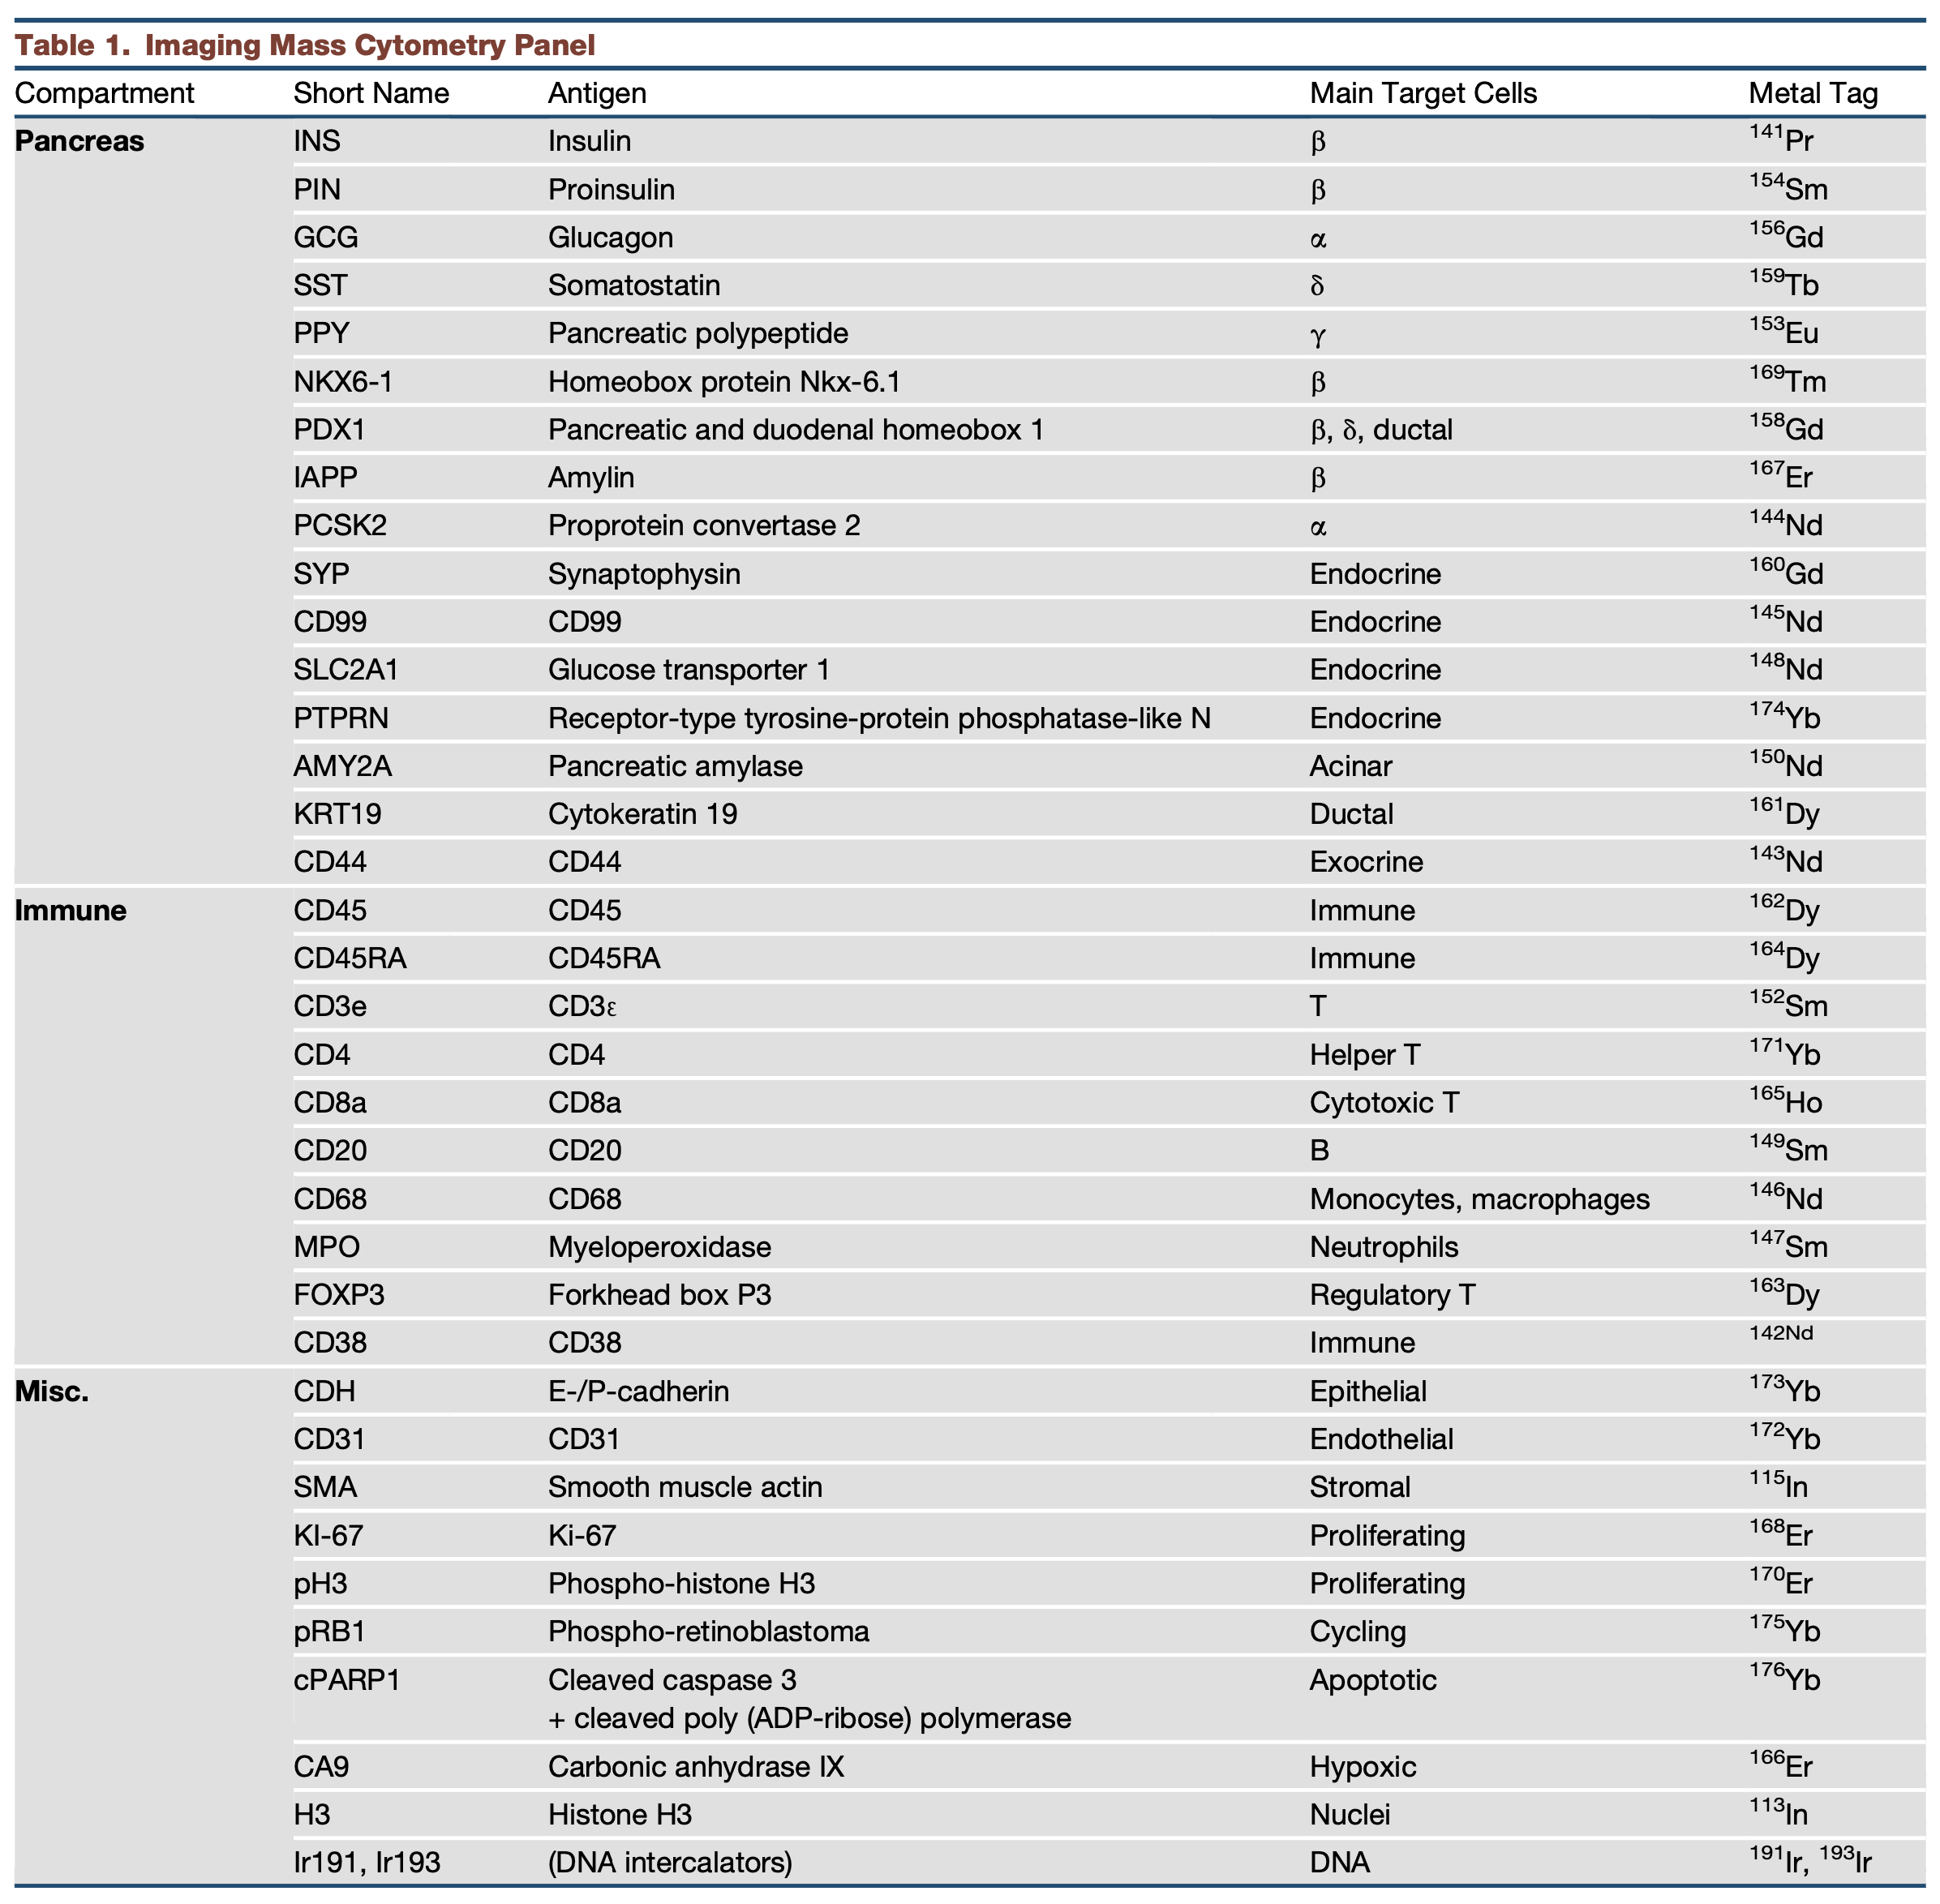

In [53]:
from IPython.display import Image
Image(filename = "./assets/BMED_360_Damond_etal_2019_Tab1_IMC_panel.png", width=700)

In [54]:
df_p = pd.read_csv(fn_panel)
print(df_p.shape)
df_p

(37, 4)


,Short Name,Antigen,Main Target Cells,Metal Tag
0,INS,Insulin,β,141Pr
1,PIN,Proinsulin,β,154Sm
2,GCG,Glucagon,α,156Gd
3,SST,Somatostatin,δ,159Tb
4,PPY,Pancreatic polypeptide,γ,153Eu
5,NKX6-1,Homeobox protein Nkx-6.1,β,169Tm
6,PDX1,Pancreatic and duodenal homeobox 1,β δ ductal,158Gd
7,IAPP,Amylin,β,167Er
8,PCSK2,Proprotein convertase 2,α,144Nd
9,SYP,Synaptophysin,Endocrine,160Gd


### Insert IMC channel number in Panel data frame

In [55]:
df_p['Chn'] = np.array(range(len(df.chn)))
for idx, val in enumerate(list(df.chn)):
    s = (val[2:]+val[:2])
    for idx2, val2 in enumerate(list(df_p['Metal Tag'])):
        if  s==val2:
            df_p.Chn.iloc[idx2] = idx+1
df_p

/var/folders/1g/_4x26lps6mgg1tr73d7g2bmh0000gp/T/ipykernel_68343/2146505735.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_p.Chn.iloc[idx2] = idx+1
/var/folders/1g/_4x26lps6mgg1tr73d7g2bmh0000gp/T/ipykernel_68343/2146505735.py:6: Set

,Short Name,Antigen,Main Target Cells,Metal Tag,Chn
0,INS,Insulin,β,141Pr,3
1,PIN,Proinsulin,β,154Sm,15
2,GCG,Glucagon,α,156Gd,16
3,SST,Somatostatin,δ,159Tb,18
4,PPY,Pancreatic polypeptide,γ,153Eu,14
5,NKX6-1,Homeobox protein Nkx-6.1,β,169Tm,28
6,PDX1,Pancreatic and duodenal homeobox 1,β δ ductal,158Gd,17
7,IAPP,Amylin,β,167Er,26
8,PCSK2,Proprotein convertase 2,α,144Nd,6
9,SYP,Synaptophysin,Endocrine,160Gd,19


In [56]:
fn = './data/imc/E08_a0_panel_data_and_channel_numbering.csv'
df_p.to_csv(fn, encoding='utf-8', index=False)

In [57]:
df_p_sort_chn = df_p.sort_values('Chn')
df_p_sort_chn

,Short Name,Antigen,Main Target Cells,Metal Tag,Chn
34,H3,Histone H3,Nuclei,113In,1
28,SMA,Smooth muscle actin,Stromal,115In,2
0,INS,Insulin,β,141Pr,3
25,CD38,CD38,Immune,142Nd,4
15,CD44,CD44,Exocrine,143Nd,5
8,PCSK2,Proprotein convertase 2,α,144Nd,6
10,CD99,CD99,Endocrine,145Nd,7
22,CD68,CD68,Monocytes macrophages,146Nd,8
23,MPO,Myeloperoxidase,Neutrophils,147Sm,9
11,SLC2A1,Glucose transporter 1,Endocrine,148Nd,10


In [58]:
fn = './data/imc/E08_a0_panel_data_sorted_on_channel_numbering.csv'
df_p_sort_chn.to_csv(fn, encoding='utf-8', index=False)

### Pandas dataframe to LaTeX table
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_latex.html

In [59]:
#print(df_p.to_latex(index=True)) 
print(df_p.style.to_latex())

\begin{tabular}{lllllr}
 & Short Name & Antigen & Main Target Cells & Metal Tag & Chn \\
0 & INS & Insulin & β & 141Pr & 3 \\
1 & PIN & Proinsulin & β & 154Sm & 15 \\
2 & GCG & Glucagon & α & 156Gd & 16 \\
3 & SST & Somatostatin & δ & 159Tb & 18 \\
4 & PPY & Pancreatic polypeptide & γ & 153Eu & 14 \\
5 & NKX6-1 & Homeobox protein Nkx-6.1 & β & 169Tm & 28 \\
6 & PDX1 & Pancreatic and duodenal homeobox 1 & β δ ductal & 158Gd & 17 \\
7 & IAPP & Amylin & β & 167Er & 26 \\
8 & PCSK2 & Proprotein convertase 2 & α & 144Nd & 6 \\
9 & SYP & Synaptophysin & Endocrine & 160Gd & 19 \\
10 & CD99 & CD99 & Endocrine & 145Nd & 7 \\
11 & SLC2A1 & Glucose transporter 1 & Endocrine & 148Nd & 10 \\
12 & PTPRN & Receptor-type tyrosine-protein phosphatase-like N & Endocrine & 174Yb & 33 \\
13 & AMY2A & Pancreatic amylase & Acinar & 150Nd & 12 \\
14 & KRT19 & Cytokeratin 19 & Ductal & 161Dy & 20 \\
15 & CD44 & CD44 & Exocrine & 143Nd & 5 \\
16 & CD45 & CD45 & Immune & 162Dy & 21 \\
17 & CD45RA & CD45RA & Imm

In [60]:
print(df_p_sort_chn.to_latex(index=True)) 

\begin{tabular}{lllllr}
\toprule
 & Short Name & Antigen & Main Target Cells & Metal Tag & Chn \\
\midrule
34 & H3 & Histone H3 & Nuclei & 113In & 1 \\
28 & SMA & Smooth muscle actin & Stromal & 115In & 2 \\
0 & INS & Insulin & β & 141Pr & 3 \\
25 & CD38 & CD38 & Immune & 142Nd & 4 \\
15 & CD44 & CD44 & Exocrine & 143Nd & 5 \\
8 & PCSK2 & Proprotein convertase 2 & α & 144Nd & 6 \\
10 & CD99 & CD99 & Endocrine & 145Nd & 7 \\
22 & CD68 & CD68 & Monocytes macrophages & 146Nd & 8 \\
23 & MPO & Myeloperoxidase & Neutrophils & 147Sm & 9 \\
11 & SLC2A1 & Glucose transporter 1 & Endocrine & 148Nd & 10 \\
21 & CD20 & CD20 & B & 149Sm & 11 \\
13 & AMY2A & Pancreatic amylase & Acinar & 150Nd & 12 \\
18 & CD3e & CD3ɛ & T & 152Sm & 13 \\
4 & PPY & Pancreatic polypeptide & γ & 153Eu & 14 \\
1 & PIN & Proinsulin & β & 154Sm & 15 \\
2 & GCG & Glucagon & α & 156Gd & 16 \\
6 & PDX1 & Pancreatic and duodenal homeobox 1 & β δ ductal & 158Gd & 17 \\
3 & SST & Somatostatin & δ & 159Tb & 18 \\
9 & SYP & Syna

### Write latex table directly to file, then use `\input(table.tex)` in Overleaf 
**remember `\usepackage{booktabs}`**

In [61]:
# Replace greek letter with mathematical greek in the Main Target Cells column
df_p_edit = df_p.copy()

old_list = ['α', 'β', 'δ', 'γ', 'β δ ductal']
new_list = ['$\\alpha$', '$\\beta$', '$\\delta$', '$\\gamma$', '$\\beta$ $\\delta$ ductal']
df_p_edit['Main Target Cells'] = df_p_edit['Main Target Cells'].replace(old_list, new_list)

# And add 1 to the index (i.e. panel antigen numbering)
df_p_edit.index = np.arange(1, len(df_p_edit)+1)
#df_p_edit.index.names = ['Channel']
df_p_edit['PanelNo'] = df_p_edit.index 

# Reorder columns to start with Channel
cols = list(df_p_edit.columns.values)
print(cols)
cols = [df_p_edit.columns[-1]] + [col for col in df_p_edit if col != df_p_edit.columns[-1]]
print(cols)
df_p_edit = df_p_edit[cols]

['Short Name', 'Antigen', 'Main Target Cells', 'Metal Tag', 'Chn', 'PanelNo']
['PanelNo', 'Short Name', 'Antigen', 'Main Target Cells', 'Metal Tag', 'Chn']


**Inspect**

In [62]:
df_p_edit

,PanelNo,Short Name,Antigen,Main Target Cells,Metal Tag,Chn
1,1,INS,Insulin,$\beta$,141Pr,3
2,2,PIN,Proinsulin,$\beta$,154Sm,15
3,3,GCG,Glucagon,$\alpha$,156Gd,16
4,4,SST,Somatostatin,$\delta$,159Tb,18
5,5,PPY,Pancreatic polypeptide,$\gamma$,153Eu,14
6,6,NKX6-1,Homeobox protein Nkx-6.1,$\beta$,169Tm,28
7,7,PDX1,Pancreatic and duodenal homeobox 1,$\beta$ $\delta$ ductal,158Gd,17
8,8,IAPP,Amylin,$\beta$,167Er,26
9,9,PCSK2,Proprotein convertase 2,$\alpha$,144Nd,6
10,10,SYP,Synaptophysin,Endocrine,160Gd,19


**EXTRA: save to file to sync with Overleaf**

In [63]:
#tab_fn = '%s/ELMED219-2024_experiments_case6126_E08_panel_table.tex' % fn_tab_base
#with open(tab_fn, 'w') as tf:
#    tf.write(df_p_edit.to_latex(index=False, escape=False))

## Plot the IMC dataset as a 7 x 6 grid of color-coded channels
#### (Optionally: save Fig for the Overleaf document)

With histogram equalization for better visualization
https://stackoverflow.com/questions/28518684/histogram-equalization-of-grayscale-images-with-numpy

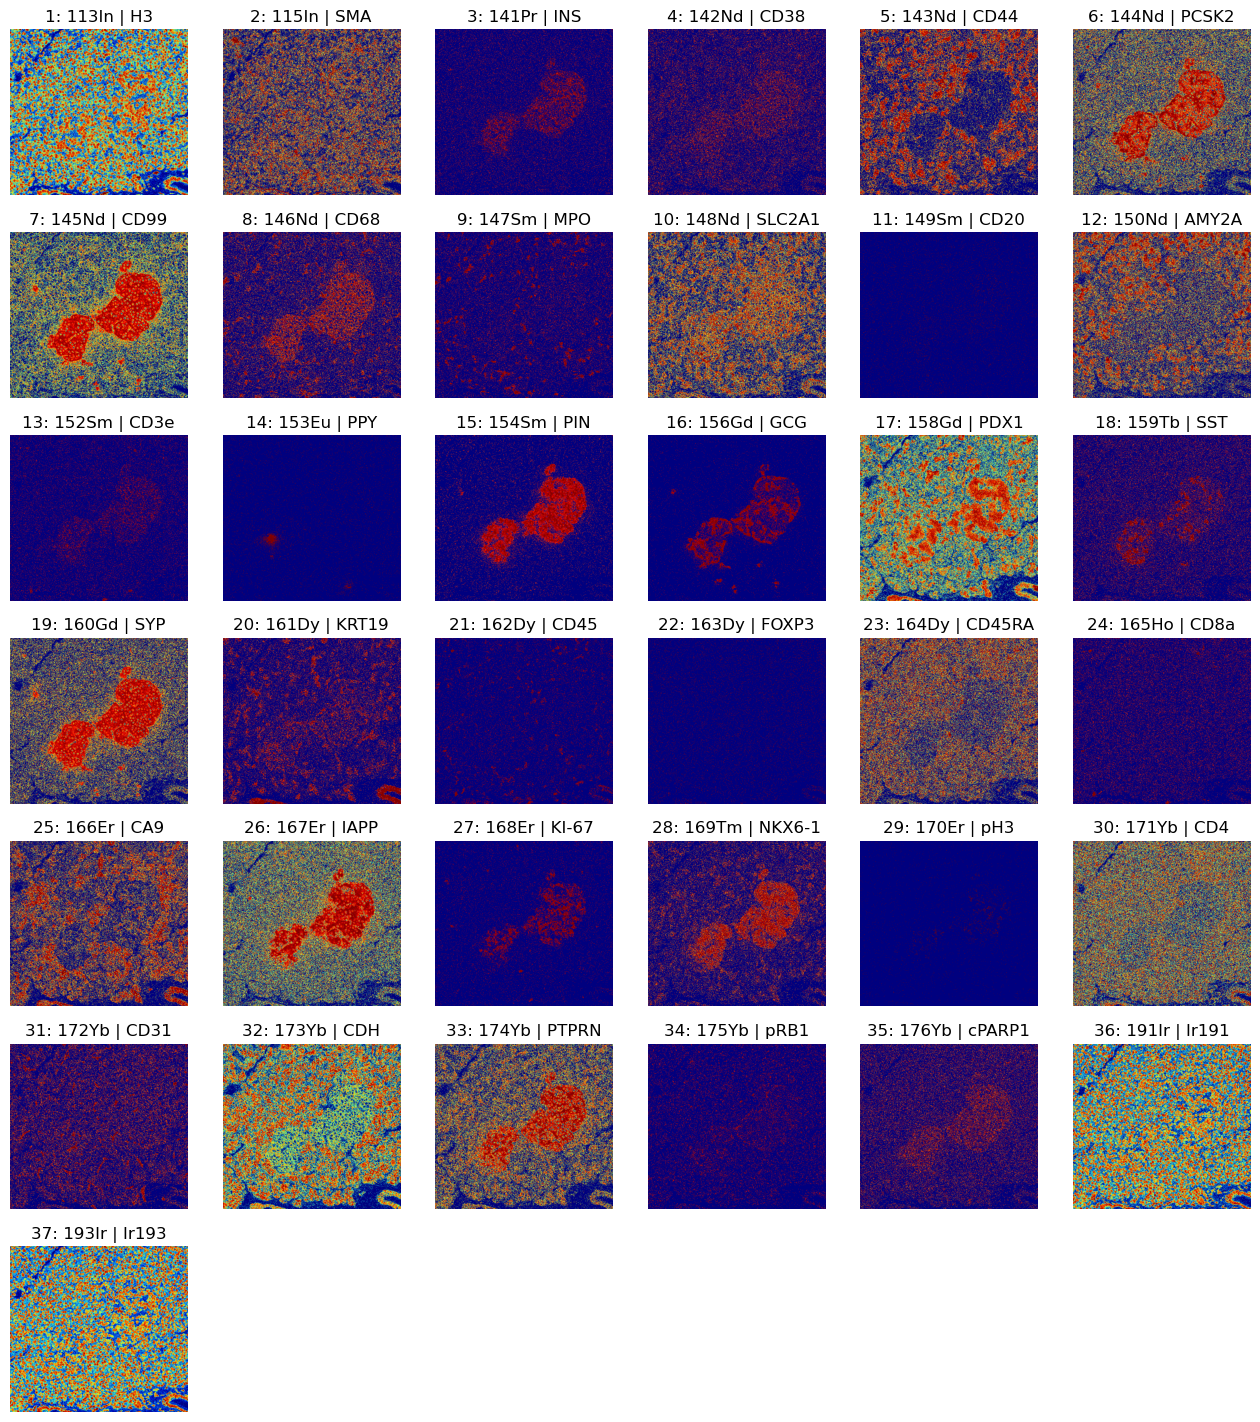

In [64]:
#fig_fn = '%s/ELMED219-2024_experiments_case6126_E08_channel_eq_mosaic_jet.pdf' % fn_fig_base
fig, axes = plt.subplots(7, 6, figsize=(16, 18), sharex=False, sharey=False)
ax = axes.ravel()
for i, item in enumerate(range(n_chn)):
    chn = np.squeeze(im[i,:,:])
    chn_eq = np.sort(chn.ravel()).searchsorted(chn)  # a kind of histogram equalization
    ax[i].imshow(chn_eq, cmap='jet' )   # cmap='jet', 'gray'
    ax[i].set_title('%d: %s | %s' % ((i+1), df_p_sort_chn['Metal Tag'].iloc[i], df_p_sort_chn['Short Name'].iloc[i]))
    ax[i].axis('off')
chn_0 = np.zeros(chn.shape )   
for j in range(n_chn,7*6):
    ax[j].imshow(chn_0, cmap='gray_r') 
    ax[j].axis('off')
#plt.savefig(fig_fn, bbox_inches='tight')
plt.show()

### Plot the IMC dataset as a 7 x 6 grid of gray-level-coded channels¶

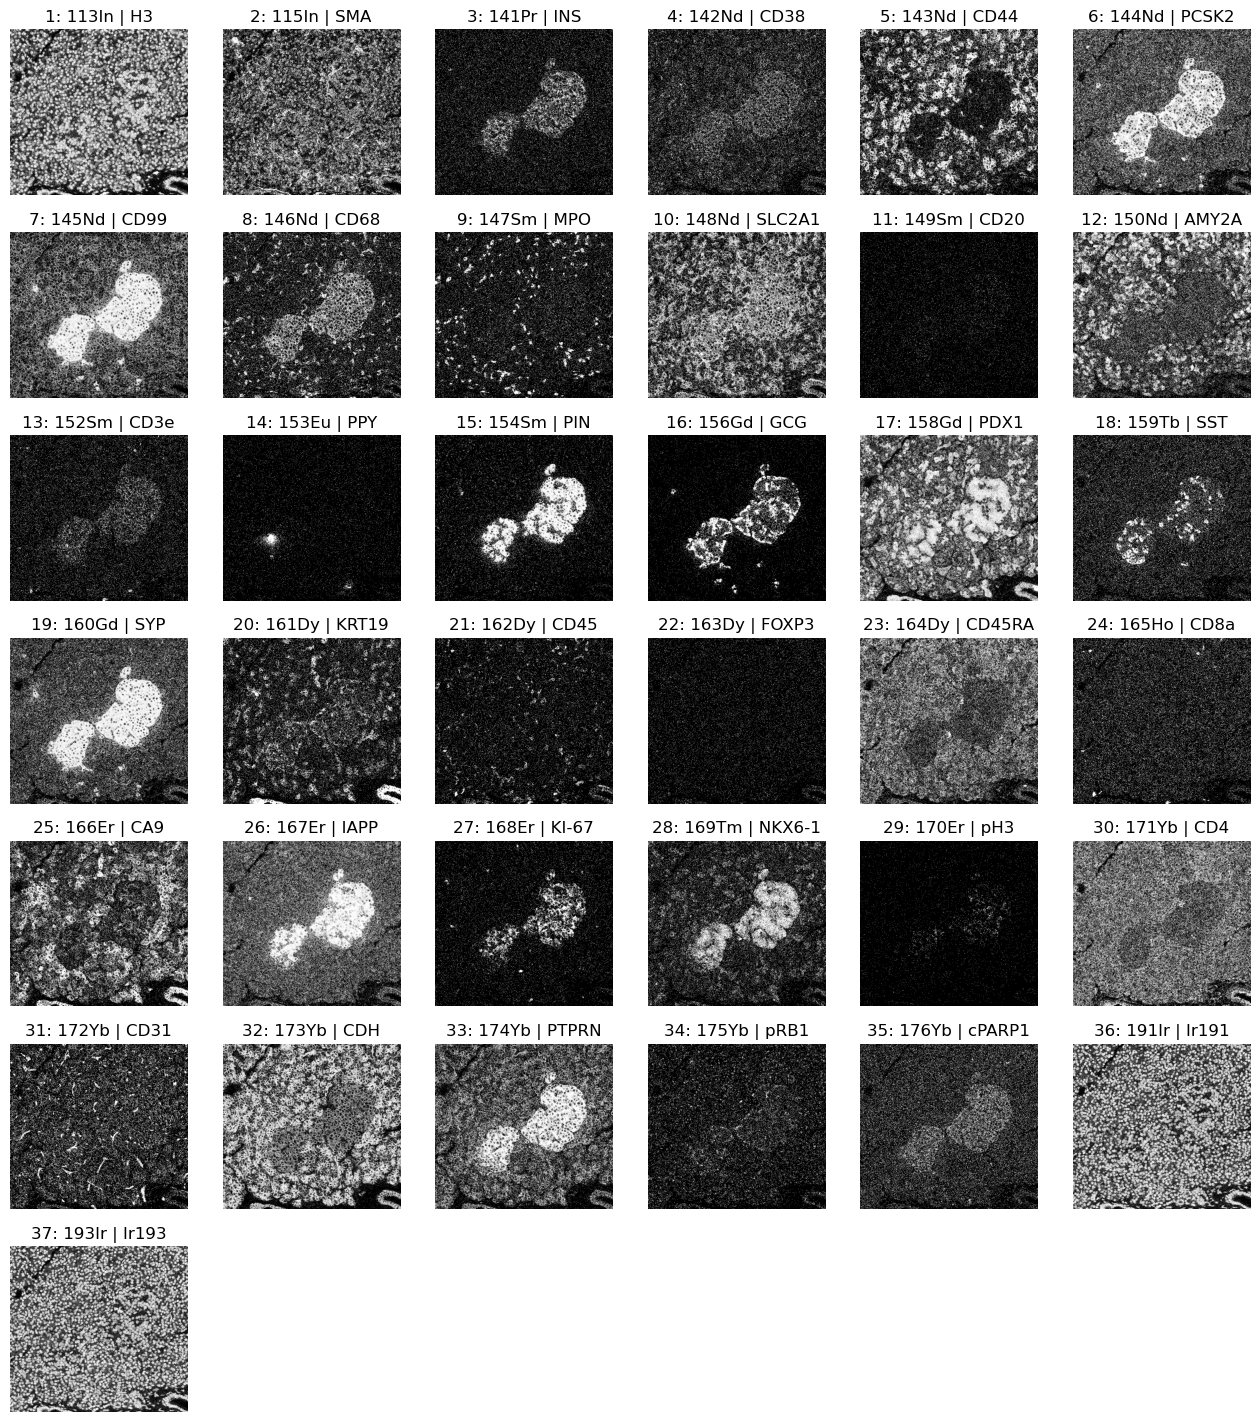

In [65]:
#fig_fn = '%s/ELMED219-2024_experiments_case6126_E08_channel_eq_mosaic_gray.pdf' % fn_fig_base
fig, axes = plt.subplots(7, 6, figsize=(16, 18), sharex=False, sharey=False)
ax = axes.ravel()
for i, item in enumerate(range(n_chn)):
    chn = np.squeeze(im[i,:,:])
    chn_eq = np.sort(chn.ravel()).searchsorted(chn)  # a kind of histogram equalization
    ax[i].imshow(chn_eq, cmap='gray' )   # cmap='jet', 'gray'
    ax[i].set_title('%d: %s | %s' % ((i+1), df_p_sort_chn['Metal Tag'].iloc[i], df_p_sort_chn['Short Name'].iloc[i]))
    ax[i].axis('off')
chn_0 = np.zeros(chn.shape )   
for j in range(n_chn,7*6):
    ax[j].imshow(chn_0, cmap='gray_r') 
    ax[j].axis('off')
#plt.savefig(fig_fn, bbox_inches='tight')
plt.show()

## Prepare the multichannel IMC image for NIFTI format

In [66]:
im.shape

(37, 530, 567)

In [67]:
def hist_eq(chn):
    return np.sort(chn.ravel()).searchsorted(chn)

In [68]:
imc_img = np.zeros(shape=(im.shape[2], im.shape[1], 1, im.shape[0]))
imc_img_eq = np.zeros(shape=(im.shape[2], im.shape[1], 1, im.shape[0]))
print(imc_img.shape)
for i in range(im.shape[0]):
    a = np.squeeze(im[i,:,:])
    b = np.squeeze(hist_eq(im[i,:,:]))
    imc_img[:,:,0,i] = a[::-1,::-1].T /a.max()
    imc_img_eq[:,:,0,i] = b[::-1,::-1].T /b.max()

(567, 530, 1, 37)


### Make a neuroimaging NIFTI-formated multichannel image 
**(for using neuroimaging display tools like Freesurfer's [FreeView](https://surfer.nmr.mgh.harvard.edu/fswiki/FreeviewGuide/FreeviewGeneralUsage/FreeviewInterface) or FSL's [FSLeyes](https://users.fmrib.ox.ac.uk/~paulmc/fsleyes/userdoc/latest)**

In [34]:
imc_nii = nib.Nifti1Image(imc_img, affine=np.eye(4))
imc_nii_eq = nib.Nifti1Image(imc_img_eq, affine=np.eye(4))  # "histogram equalized channels" image

#### Save this NIFTI image to disk

In [35]:
nib.save(imc_nii, './data/imc/imc_%d_chns.nii.gz' % (im.shape[0]))
nib.save(imc_nii_eq, './data/imc/imc_%d_chns_eq.nii.gz' % (im.shape[0]))